In [11]:
import numpy as np
import matplotlib.pyplot as plt

import utils

## Phantom Data

In [12]:
data_dir = "./data/BioUSElective_20260506_JTLRYTAA/ST/"
filepath = data_dir + "data_20260506_164831_ST_5.9Vmat_20260506_165551.mat"

BFData, ReconParams = utils.extract_mat_file(filepath)

Loaded IQ_xAM with shape: (260, 180), dtype: complex64
Loaded IQ_xBMode with shape: (260, 180), dtype: complex64


In [15]:
def plot_beamformed_image(BFData, ReconParams, mode='BMode', figsize=(10, 8),
                          cmap='bone', show_colorbar=True,
                          IMG_max=None, IMG_min=None, db_range=45, full_db_range=False):
    mode = mode.lower()
    if mode == 'am':
        iq_data = BFData.get('IQ_xAM')
        title = 'Log‑compressed IQ_xAM'
    elif mode == 'bmode':
        iq_data = BFData.get('IQ_xBMode')
        title = 'Log‑compressed IQ_xBMode'
    else:
        raise ValueError("mode must be 'AM' or 'BMode'")

    if iq_data is None:
        raise KeyError(f"Data for mode {mode} not found in BFData")

    #envelope = # TAKE THE ENVELOPE
    envelope = np.abs(iq_data)
    envelope = envelope.T
    
    #log-compression
    if IMG_max is None:
        IMG_max = np.max(envelope)
    log_env = 20 * np.log10(envelope / IMG_max)        # hide only part of the log-compression formula, tell them to look at slide 30 of 06 - Medical Ultrasound Slides
    if IMG_min is None:
        min_db = -db_range
    else: #IMG_min / IMG_max
        min_db = 20 * np.log10(IMG_min / IMG_max)
    
    if full_db_range==True: #np.min(envelope) / np.max(envelope)
        min_db = 20 * np.log10(np.min(envelope) / np.max(envelope))
        
    img_compressed = np.clip(log_env, min_db, 0)

    # Physical axes (meters -> mm)
    grid_origin = ReconParams['GridOrigin']
    grid_scale_x = ReconParams['GridScaleX'] 
    grid_scale_z = ReconParams['GridScaleZ']

    n_depth, n_lateral = iq_data.shape
    lateral_mm = (grid_origin[0] + np.arange(n_lateral) * grid_scale_x) * 1000
    depth_mm  = (grid_origin[2] + np.arange(n_depth)  * grid_scale_z) * 1000
    depth_mm = np.flip(depth_mm)
    
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(img_compressed,
                   extent=[lateral_mm[0], lateral_mm[-1], depth_mm[0], depth_mm[-1]],
                   aspect='equal',
                   cmap=cmap,
                   vmin=min_db, vmax=0)          # set dB range explicitly
    ax.set_ylabel('Depth (mm)')
    ax.set_xlabel('Lateral Position (mm)')
    ax.set_title(title)

    if show_colorbar:
        cbar = plt.colorbar(im, ax=ax, label='Amplitude (dB)')   # now labels dB correctly

    plt.tight_layout()
    return img_compressed, envelope, lateral_mm, depth_mm

In [26]:
full_db_range = True

img_log, envelope, lateral_mm, depth_mm = plot_beamformed_image(BFData, ReconParams, mode='AM', full_db_range=full_db_range)

In [17]:
## Find the mean intensity of a background region by defining index ranges (idx_start, idx_end)
depth_range =      #TODO
lateral_range =    #TODO

sub = utils.extract_subimage(envelope, depth_range=depth_range, lateral_range=lateral_range)

IMG_min =          #TODO

In [18]:
## Find the max intensity of a well by defining index ranges (idx_start, idx_end)
depth_range =      #TODO
lateral_range =    #TODO

sub = utils.extract_subimage(envelope, depth_range=depth_range, lateral_range=lateral_range)

IMG_max =          #TODO

In [19]:
## Plot reconstruction with CNR based dynamic range

img_log, envelope, lateral_mm, depth_mm = plot_beamformed_image(BFData, ReconParams, mode='AM', IMG_min=IMG_min, IMG_max=IMG_max)

In [ ]:
# Compute CNR in dB
cnr =              #TODO

print('CNR =', cnr)

In [23]:
## Repeat CNR computation for all Stripped GV images and store values
stripped_gv_cnr_list = []


In [24]:
## Repeat CNR computation for all Wild Type GV images and store values
wild_type_gv_cnr_list = []


## Hydrostatic Collapse Pressure

In [25]:
import pandas as pd

# Provide the file path (adjust if needed)
file_path = "/home/dvallmanyapoch/Projects/biomol_elective/data/06052026_Jt_stripped_3_06052026.xlsx"

# Read all sheets into a dictionary of DataFrames
sheets_dict = pd.read_excel(file_path, sheet_name=None, header=0)

# # Iterate over each sheet and show its content
# for sheet_name, df in sheets_dict.items():
#     print(f"\n{'='*60}")
#     print(f"Sheet: {sheet_name}")
#     print(f"Shape: {df.shape}")
#     print(f"Columns: {list(df.columns)}")
#     print(df.head())  # Show first few rows

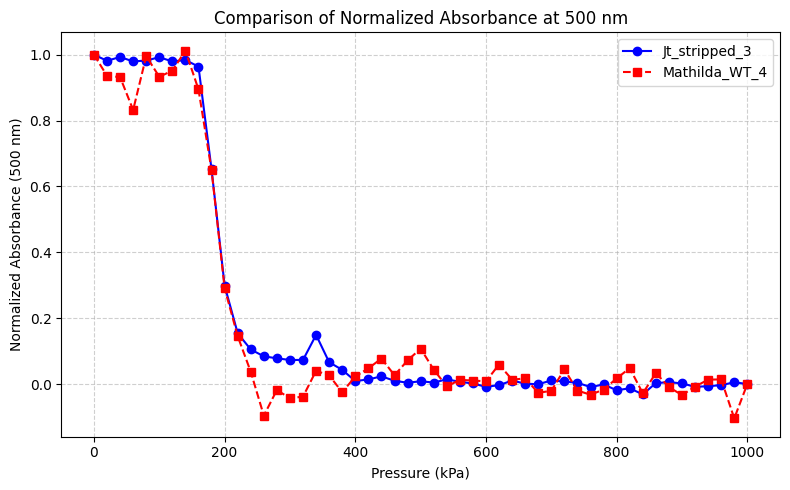

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# File path
file1 = "/home/dvallmanyapoch/Projects/biomol_elective/data/06052026_Jt_stripped_3_06052026.xlsx"
file2 = "/home/dvallmanyapoch/Projects/biomol_elective/data/06052026_Ira_stripped_6_06052026.xlsx"

# Read the "Normalized Abs 500" sheet from each file
df1 = pd.read_excel(file1, sheet_name="Normalized Abs 500")
df2 = pd.read_excel(file2, sheet_name="Normalized Abs 500")

# Plot both curves
plt.figure(figsize=(8, 5))
plt.plot(df1["Pressure (kPa)"], df1["Absorbance 500nm"], 
         marker='o', linestyle='-', color='blue', label="Jt_stripped_3")
plt.plot(df2["Pressure (kPa)"], df2["Absorbance 500nm"], 
         marker='s', linestyle='--', color='red', label="Mathilda_WT_4")

plt.xlabel("Pressure (kPa)")
plt.ylabel("Normalized Absorbance (500 nm)")
plt.title("Comparison of Normalized Absorbance at 500 nm")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()